# The BC Baseline -- Explained

This notebook walks through the **behavior-cloning (BC) MSE baseline** (Phase 7),
the control that makes the multimodality result in this project legible.

The BC policy reuses the *exact* observation encoder, data pipeline, min-max
normalisation, action chunking, and receding-horizon execution of the Diffusion
Policy. Only two things change:

- **Head:** a small MLP maps the 2176-D conditioning vector straight to a
  `(pred_horizon, action_dim)` action chunk in a single forward pass, instead of the
  iterative FiLM U-Net denoiser.
- **Loss:** plain MSE against the demonstration chunk, instead of epsilon-prediction.

Swapping only the head and loss isolates the modeling choice as the cause of the
behaviour. The notebook runs **without the dataset or the robot** -- it uses a tiny
synthetic batch and identity normalizers.

## 1. Configuration

The baseline is selected with `model.type: bc`. The `bc:` section sets the MLP head
shape. The `diffusion.*` and `denoiser.*` sections are simply ignored when
`model.type == "bc"`.

In [1]:
from pathlib import Path
import sys

import torch

# Locate the repo root so the notebook runs from anywhere (e.g. the docs/ dir).
root = Path.cwd()
while not (root / "diffusion_policy_soarm").is_dir() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
print("repo root:", root)

from diffusion_policy_soarm.utils.config import load_config, merge_config

base = root / "diffusion_policy_soarm/configs/base.yaml"
override = root / "diffusion_policy_soarm/configs/ablations/bc_baseline.yaml"
cfg = merge_config(load_config(str(base)), str(override))

print("model.type      =", cfg.model.get("type"))
print("bc.hidden_dims  =", list(cfg.bc.hidden_dims), "| dropout =", cfg.bc.dropout)
print("obs_horizon     =", cfg.model.obs_horizon)
print("pred_horizon    =", cfg.model.pred_horizon)
print("ignored by BC   -> diffusion.noise_schedule =", cfg.diffusion.noise_schedule,
      "| denoiser.backbone =", cfg.denoiser.backbone)


repo root: /home/vasili/dev/multimodal-manipulation-benchmark
model.type      = bc
bc.hidden_dims  = [512, 512] | dropout = 0.0
obs_horizon     = 2
pred_horizon    = 16
ignored by BC   -> diffusion.noise_schedule = cosine | denoiser.backbone = cnn


## 2. What BC sees and what it predicts

Identical front end to the diffusion policy: two ResNet18 image encoders plus a small
state MLP produce a **2176-D conditioning vector** (`obs_horizon x (2 x 512 + 64)`).
The only difference downstream is the head and the loss.

`build_policy` reads `cfg.model.type` and assembles the right module. Below we build
the BC policy with identity normalizers (so we need no dataset stats) and confirm the
parameter split and the forward shapes.

In [2]:
from diffusion_policy_soarm.data.normalization import Normalizer
from diffusion_policy_soarm.models.factory import build_policy

ACTION_DIM = STATE_DIM = 6  # SO-101: 5 joints + gripper

def identity_normalizer(dim: int) -> Normalizer:
    # mins=-1, maxs=+1 -> forward and inverse are the identity.
    return Normalizer(mins=-torch.ones(dim), maxs=torch.ones(dim))

model = build_policy(
    cfg,
    action_dim=ACTION_DIM,
    state_dim=STATE_DIM,
    action_normalizer=identity_normalizer(ACTION_DIM),
    state_normalizer=identity_normalizer(STATE_DIM),
)
model.eval()
print("policy class:", type(model).__name__)

count = lambda m: sum(p.numel() for p in m.parameters())
print(f"encoder params : {count(model.encoder)/1e6:6.2f} M  (shared with Diffusion Policy)")
print(f"MLP head params: {count(model.head)/1e6:6.2f} M")
print(f"total params   : {count(model)/1e6:6.2f} M")

# Synthetic batch matching the real shapes (no dataset needed).
T_o, H = cfg.model.obs_horizon, cfg.model.pred_horizon
B = 2
batch = {
    "images": {k: torch.rand(B, T_o, 3, *cfg.dataset.image_size) for k in cfg.dataset.camera_keys},
    "state": torch.randn(B, T_o, STATE_DIM),
    "actions": torch.randn(B, H, ACTION_DIM),
}

with torch.no_grad():
    loss = model.compute_loss(batch)
    actions = model.predict_actions(batch)
print(f"\ncompute_loss     -> scalar = {loss.item():.4f}")
print(f"predict_actions  -> chunk  = {tuple(actions.shape)}  (B, pred_horizon, action_dim)")

/home/vasili/dev/multimodal-manipulation-benchmark/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


policy class: BCModule
encoder params :  23.40 M  (shared with Diffusion Policy)
MLP head params:   1.43 M
total params   :  24.83 M

compute_loss     -> scalar = 0.9176
predict_actions  -> chunk  = (2, 16, 6)  (B, pred_horizon, action_dim)


## 3. The objective: MSE vs. epsilon-prediction

Diffusion Policy trains a denoiser to predict the noise added to a noised action
chunk; sampling then turns Gaussian noise into one clean chunk over many steps. Each
rollout draws fresh noise, so different runs can land on different **modes** of the
action distribution.

BC trains the MLP head to minimise

    L = E[ || head(c) - a ||^2 ]

where `c` is the conditioning vector and `a` is the demonstrated chunk. For a context
`c` that matches both a left-cube and a right-cube demonstration, the minimiser is the
**conditional mean** `E[a | c]`. A single deterministic output cannot represent a
multimodal conditional -- it can only return the average.

## 4. The failure, numerically

Below is a self-contained toy that reproduces the mean-collapse without any robot.
One fixed context (the cubes are symmetric about the workspace centre, so the
observation does not disambiguate the target). Half the demonstrations reach **left**
(action `-1`), half reach **right** (action `+1`). We fit a small MLP with MSE and read
off its prediction at that context.

final MSE                         = 0.9998
BC prediction at shared context   = -0.0150
empty-gap midpoint of the modes   = +0.0000
the two valid actions             = -1.00 and +1.00


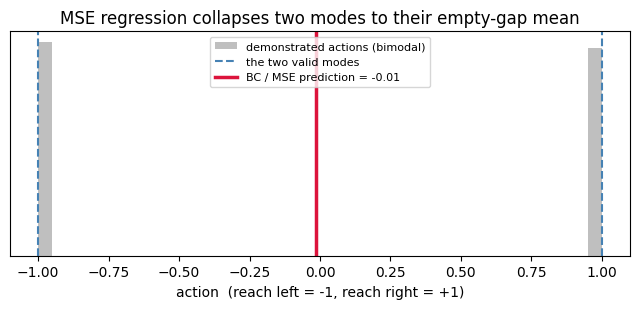

In [3]:
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)

N = 4000
# Single shared context: the observation does not reveal which cube is the target.
x = torch.zeros(N, 1)
# Bimodal target: 50% reach left (-1), 50% reach right (+1).
y = torch.where(torch.rand(N, 1) < 0.5, torch.full((N, 1), -1.0), torch.full((N, 1), 1.0))

net = nn.Sequential(nn.Linear(1, 64), nn.SiLU(), nn.Linear(64, 64), nn.SiLU(), nn.Linear(64, 1))
opt = torch.optim.Adam(net.parameters(), lr=1e-2)
for _ in range(2000):
    opt.zero_grad()
    loss = F.mse_loss(net(x), y)
    loss.backward()
    opt.step()

pred = net(torch.zeros(1, 1)).item()
print(f"final MSE                         = {loss.item():.4f}")
print(f"BC prediction at shared context   = {pred:+.4f}")
print(f"empty-gap midpoint of the modes   = {0.0:+.4f}")
print(f"the two valid actions             = -1.00 and +1.00")

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.hist(y.numpy().ravel(), bins=40, color="0.75", label="demonstrated actions (bimodal)")
ax.axvline(-1, color="steelblue", ls="--", lw=1.5)
ax.axvline(1, color="steelblue", ls="--", lw=1.5, label="the two valid modes")
ax.axvline(pred, color="crimson", lw=2.5, label=f"BC / MSE prediction = {pred:+.2f}")
ax.set_xlabel("action  (reach left = -1, reach right = +1)")
ax.set_yticks([])
ax.set_title("MSE regression collapses two modes to their empty-gap mean")
ax.legend(loc="upper center", fontsize=8)
plt.tight_layout()
plt.show()

The MSE-trained network lands near `0`: the midpoint between the two cubes, where
there is nothing to grasp. On the real arm this is the "grabbed nothing" failure -- the
gripper reaches into the empty gap. Diffusion Policy avoids this because sampling
commits to one mode per rollout rather than averaging them.

## 5. Inference

BC inference is a **single forward pass** -- encode the observation, run the MLP head,
denormalise the chunk. It then drives the same receding-horizon loop as Diffusion
Policy (execute the first `exec_horizon` steps, re-observe, replan), so `infer.py` is
unchanged. There is no DDIM loop and no warm start: `predict_actions` accepts a
`warm_start_actions_norm` argument only for interface compatibility and ignores it
(a one-shot regressor has no iterative state to seed).

In [4]:
# Same output regardless of any warm-start hint -> confirms it is ignored.
a0 = model.predict_actions(batch)
a1 = model.predict_actions(batch, warm_start_actions_norm=torch.randn_like(a0))
print("warm-start changes output?", not torch.equal(a0, a1))

warm-start changes output? False


## 6. Diffusion Policy vs. BC at a glance

| | Diffusion Policy | BC baseline |
|---|---|---|
| Observation encoder | ResNet18 x2 + state MLP -> 2176-D | **identical** |
| Action head | FiLM 1-D U-Net denoiser | MLP (`Linear + SiLU` x N) |
| Output | `(pred_horizon, action_dim)` chunk | **same** `(pred_horizon, action_dim)` chunk |
| Training loss | epsilon-prediction MSE | MSE on the chunk |
| Inference | iterative DDIM (N steps) | single forward pass |
| Multimodality | samples one mode per rollout | collapses to the conditional mean |
| Bimodal pick | commits to left **or** right | reaches the empty gap |

## 7. One-paragraph summary

The BC baseline is the diffusion policy with its denoiser replaced by a single-pass MLP
and its objective replaced by MSE; everything else -- encoder, normalisation, chunking,
control -- is held fixed. Because MSE regresses a multimodal conditional onto its mean,
the baseline cannot commit to either cube on the 50/50 task and instead reaches into the
empty gap between them. That controlled contrast is the headline result the project sets
out to measure: representing multimodality, not raw capacity, is what lets Diffusion
Policy succeed where naive behavior cloning fails.